# Датасет

Вручную собранный датасет блоков из Minecraft, разделённых на 4 класса. По принципу того, какой они издают звук: стекло, металл, камень, дерево. Датасет небольшой, где-то на 300 блоков, но, возможно, что-то из этого выйдет, так как классов мало, и информация довольно однородная.

Класс 0 — стекло, класс 1 — металл, класс 2 — камень, класс 3 — дерево.

# Часть с кодом

In [1]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [2]:
!rm -rf data/*

In [3]:
import zipfile #датасет в zip

with zipfile.ZipFile('/content/gdrive/My Drive/data_stud/machlearn/minecraft/dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('data/')

In [4]:
from torch.utils.data import Dataset
from torchvision.transforms import ToTensor, Resize
from PIL import Image
import glob
import torch

from torchvision.datasets import ImageFolder
from torchvision import transforms
from torch.utils.data import DataLoader
import os

from sklearn.model_selection import train_test_split

class RGBAFolderDataset(Dataset):
    def __init__(self, root, size=(16, 16)):
        self.files = []
        self.labels = []
        self.size = size

        for label_name in sorted(os.listdir(root)):
            label_path = os.path.join(root, label_name)
            if not os.path.isdir(label_path) or not label_name.isdigit():
                continue
            label = int(label_name)
            for fname in glob.glob(os.path.join(label_path, "*")):
                self.files.append(fname)
                self.labels.append(label)

        self.resize = Resize(size)
        self.to_tensor = ToTensor()

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img = Image.open(self.files[idx]).convert("RGBA")
        img = self.resize(img)
        img = self.to_tensor(img)
        label = self.labels[idx]
        return img, label

In [8]:
!ls data/dataset/0/


black_stained_glass.png  glass.png		       orange_stained_glass.png
blue_ice.png		 glowstone.png		       packed_ice.png
blue_stained_glass.png	 gray_stained_glass.png        pink_stained_glass.png
brown_stained_glass.png  green_stained_glass.png       purple_stained_glass.png
cyan_stained_glass.png	 ice.png		       red_stained_glass.png
frosted_ice_0.png	 light_blue_stained_glass.png  redstone_lamp_on.png
frosted_ice_1.png	 light_gray_stained_glass.png  redstone_lamp.png
frosted_ice_2.png	 lime_stained_glass.png        tinted_glass.png
frosted_ice_3.png	 magenta_stained_glass.png     yellow_stained_glass.png


In [9]:
dataset = RGBAFolderDataset("data/dataset/", size=(16, 16))

X = []
y = []

for img, label in dataset:
    X.append(img)
    y.append(label)

X = torch.stack(X)
y = torch.tensor(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [11]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test: ", X_test.shape)
print("y_test: ", y_test.shape)
print("Классы: ", y.unique().tolist())

X_train: torch.Size([220, 4, 16, 16])
y_train: torch.Size([220])
X_test:  torch.Size([55, 4, 16, 16])
y_test:  torch.Size([55])
Классы:  [0, 1, 2, 3]


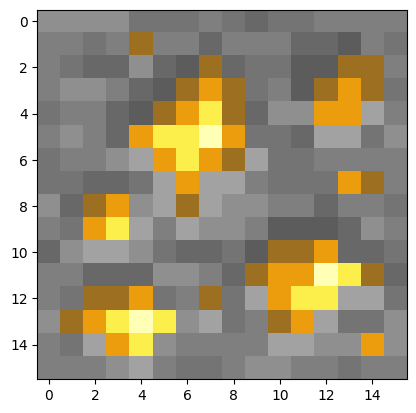

In [13]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

img = Image.open('data/dataset/2/gold_ore.png')
plt.imshow(img)
plt.show()

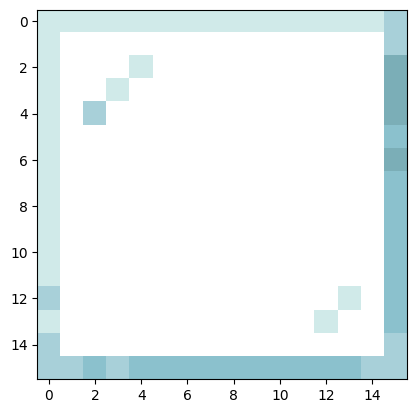

In [14]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

img = Image.open('data/dataset/0/glass.png')
plt.imshow(img)
plt.show()

In [47]:
X_train.shape

torch.Size([220, 4, 16, 16])

In [48]:
y_test.shape

torch.Size([55])

In [56]:
print (X_train)

tensor([[[[0.5020, 0.5373, 0.5373,  ..., 0.5373, 0.5020, 0.5804],
          [0.5020, 0.5255, 0.5255,  ..., 0.5255, 0.5255, 0.5020],
          [0.5020, 0.5255, 0.2941,  ..., 0.3608, 0.5804, 0.5373],
          ...,
          [0.5020, 0.5255, 0.4157,  ..., 0.3608, 0.5255, 0.5020],
          [0.5020, 0.5255, 0.5255,  ..., 0.5255, 0.5255, 0.5373],
          [0.5020, 0.5020, 0.5373,  ..., 0.5020, 0.5020, 0.5020]],

         [[0.2196, 0.2235, 0.2235,  ..., 0.2235, 0.2196, 0.2471],
          [0.2196, 0.2431, 0.2431,  ..., 0.2431, 0.2431, 0.2196],
          [0.2196, 0.2431, 0.1529,  ..., 0.1882, 0.2471, 0.2235],
          ...,
          [0.2196, 0.2431, 0.2039,  ..., 0.1882, 0.2431, 0.2196],
          [0.2196, 0.2431, 0.2431,  ..., 0.2431, 0.2431, 0.2235],
          [0.2196, 0.2196, 0.2235,  ..., 0.2196, 0.2196, 0.2196]],

         [[0.3255, 0.3569, 0.3569,  ..., 0.3569, 0.3255, 0.3804],
          [0.3255, 0.3529, 0.3529,  ..., 0.3529, 0.3529, 0.3255],
          [0.3255, 0.3529, 0.2157,  ..., 0

In [16]:
import torch.nn as nn
import torch.nn.functional as F

class LeModel (nn.Module):

    def __init__(self, num_classes):

        super().__init__()
        self.conv1 = nn.Conv2d(4, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2)
        self.fc1 = nn.Linear(32 * 4 * 4, 128)
        self.fc2 = nn.Linear(128, 4)

    def forward(self, x):

        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [17]:
def train(model, train_loader, val_loader, optimizer, device, epochs=10):
    model = model.to(device)

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        correct = 0
        total = 0

        for X, y in train_loader:
            X, y = X.to(device), y.to(device)

            optimizer.zero_grad()
            logits = model(X)
            loss = F.cross_entropy(logits, y)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * X.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

        avg_loss = total_loss / total
        acc = correct / total * 100
        print(f"[Epoch {epoch+1}] Train loss: {avg_loss:.4f} | acc: {acc:.2f}%")

        if val_loader is not None:
            model.eval()
            val_loss = 0
            val_correct = 0
            val_total = 0
            with torch.no_grad():
                for X_val, y_val in val_loader:
                    X_val, y_val = X_val.to(device), y_val.to(device)
                    logits = model(X_val)
                    loss = F.cross_entropy(logits, y_val)
                    val_loss += loss.item() * X_val.size(0)
                    preds = logits.argmax(dim=1)
                    val_correct += (preds == y_val).sum().item()
                    val_total += y_val.size(0)

            val_loss /= val_total
            val_acc = val_correct / val_total * 100
            print(f"           Val loss:   {val_loss:.4f} | acc: {val_acc:.2f}%")

In [18]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=16)

val_dataset = TensorDataset(X_test, y_test)
val_loader = DataLoader(val_dataset, batch_size=16)

In [21]:
epochs = 50
learning_rate = 0.001

In [22]:
from torch import optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = LeModel (num_classes=4)

optimizer = optim.Adam(model.parameters(), learning_rate)

train(model, train_loader, val_loader, optimizer, device, epochs)


[Epoch 1] Train loss: 1.3438 | acc: 40.00%
           Val loss:   1.2842 | acc: 41.82%
[Epoch 2] Train loss: 1.2781 | acc: 41.36%
           Val loss:   1.2238 | acc: 41.82%
[Epoch 3] Train loss: 1.2295 | acc: 41.36%
           Val loss:   1.1652 | acc: 43.64%
[Epoch 4] Train loss: 1.2002 | acc: 42.27%
           Val loss:   1.1179 | acc: 54.55%
[Epoch 5] Train loss: 1.1595 | acc: 45.91%
           Val loss:   1.0707 | acc: 54.55%
[Epoch 6] Train loss: 1.1107 | acc: 50.00%
           Val loss:   1.0269 | acc: 52.73%
[Epoch 7] Train loss: 1.0816 | acc: 50.45%
           Val loss:   1.0100 | acc: 56.36%
[Epoch 8] Train loss: 1.0347 | acc: 49.55%
           Val loss:   0.9700 | acc: 56.36%
[Epoch 9] Train loss: 0.9951 | acc: 51.36%
           Val loss:   0.9480 | acc: 56.36%
[Epoch 10] Train loss: 0.9735 | acc: 55.00%
           Val loss:   0.9291 | acc: 60.00%
[Epoch 11] Train loss: 0.9227 | acc: 61.82%
           Val loss:   0.8998 | acc: 63.64%
[Epoch 12] Train loss: 0.8990 | acc: 60.0

In [23]:
with torch.no_grad():
    X, y = X_test[:8].to(device), y_test[:8].to(device)
    preds = model(X).argmax(dim=1)
    print("Preds:", preds.tolist())
    print("True :", y.tolist())

Preds: [2, 1, 2, 2, 2, 1, 3, 3]
True : [2, 1, 3, 2, 2, 3, 3, 2]


Как-то предсказывает, значит идея работает. Для улучшения результатов, наверное, стоит именно сам датасет улучшать.

Схема модели: вход -> conv2d -> relu -> maxpool2d -> conv2d -> relu -> maxpool2d -> flatten -> linear -> relu -> linear